In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df_tfidf = pd.read_csv('dataset_tfidf.csv')
df_indobert = pd.read_csv('dataset_indobert.csv')

In [3]:
X_tfidf = df_tfidf.iloc[:, 10:]
y_tfidf = df_tfidf['Kategori_Label']

X_indo = df_indobert.iloc[:, 10:]
y_indo = df_indobert['Kategori_Label']

In [4]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tfidf, y_tfidf, test_size=0.2, random_state=42)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_indo, y_indo, test_size=0.2, random_state=42)

In [5]:
model_tfidf = RandomForestClassifier(random_state=42)
model_tfidf.fit(X_train_t, y_train_t)

model_indo = RandomForestClassifier(random_state=42)
model_indo.fit(X_train_i, y_train_i)

RandomForestClassifier(random_state=42)

In [6]:
pred_tfidf = model_tfidf.predict(X_test_t)
pred_indo = model_indo.predict(X_test_i)

In [7]:
acc_tfidf = accuracy_score(y_test_t, pred_tfidf)
acc_indo = accuracy_score(y_test_i, pred_indo)

print(f"Akurasi Metode TF-IDF    : {acc_tfidf * 100:.2f}%")
print(f"Akurasi Metode IndoBERT  : {acc_indo * 100:.2f}%")

Akurasi Metode TF-IDF    : 32.39%
Akurasi Metode IndoBERT  : 33.80%


In [8]:
hasil_ab_testing = pd.DataFrame({
    'Metode': ['TF-IDF', 'IndoBERT'],
    'Akurasi': [acc_tfidf * 100, acc_indo * 100]
})
hasil_ab_testing.to_csv('hasil_ab_testing.csv', index=False)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
prediksi_indo = model_indo.predict(X_test_i)

In [11]:
print(classification_report(y_test_i, prediksi_indo))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.50      0.24      0.32        25
           2       0.21      0.50      0.30        12
           3       0.40      0.71      0.51        17

    accuracy                           0.34        71
   macro avg       0.28      0.36      0.28        71
weighted avg       0.31      0.34      0.29        71



In [12]:
cm = confusion_matrix(y_test_i, prediksi_indo)

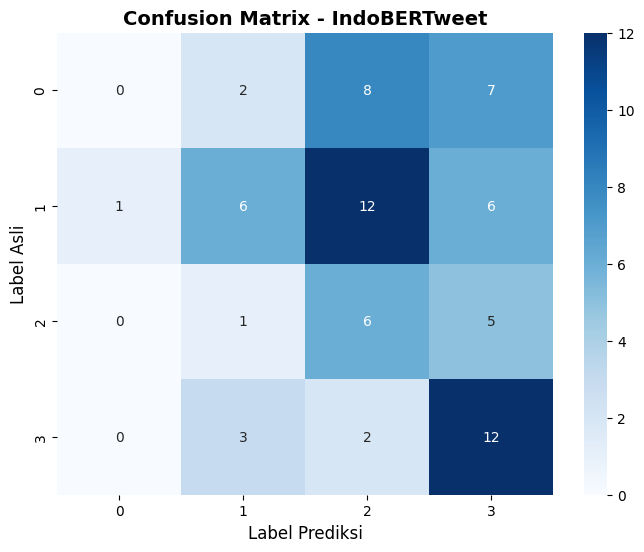

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - IndoBERTweet', fontsize=14, fontweight='bold')
plt.ylabel('Label Asli', fontsize=12)
plt.xlabel('Label Prediksi', fontsize=12)
plt.show()